<a href="https://colab.research.google.com/github/lawanmuk/hbn-parabolic-two-band-model/blob/main/Analysis_of_TBModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of the parabolic two band model to investigate the Dynamical Franz-Keldeysh Effect (DFKE) adapted from the Lecture notes of Shunsuke Sato.


#Download Data Files

In [ ]:
import sys
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.constants import e, m_e, pi, hbar
from numpy.ma import masked_array

#Input Constants

In [ ]:
h2ev = 27.21138386            # Hartree to eV
au2fs = 0.02418884254         # a.u to femtosecond
c = 137.0                     # Speed of light in a.u

#Parameters for the parabolic bands
$$
\begin{aligned}
& \epsilon_{v, \vec{k}}=-\frac{\vec{k}^{2}}{2 m_{v}}, \\
& \epsilon_{c, \vec{k}}=\epsilon_{g}+\frac{\vec{k}^{2}}{2 m_{c}},
\end{aligned}
$$

In [ ]:
mm_v = 0.5
mm_c = 0.3
k = np.linspace(-np.pi, np.pi, 10000)  # k-vectors
E_v = -k**2/ 2 * mm_v  # conduction band energy levels
E_c = (k**2/2 * mm_c) + 4.45  # valence band energy levels

#Plot of the parabolic bands.

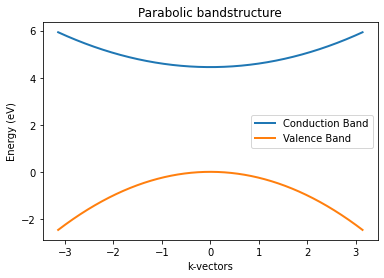

In [ ]:
# Plot the band structure
plt.plot(k, E_c, label="Conduction Band", linewidth = 2)
plt.plot(k, E_v, label="Valence Band", linewidth = 2)
plt.xlabel("k-vectors")
plt.ylabel("Energy (eV)")
plt.title('Parabolic bandstructure')
plt.legend()
plt.show()


#In 2-D, the Imaginary part of the Dielectric function is given by
$$
\Im[\epsilon(\omega)](\omega)=\left(\frac{2 \pi e}{m \omega}\right)^{2} \frac{2}{(2 \pi)^{3}} \int d \vec{k}~\left|p_{v c, \vec{k}}\right|^{2} \delta\left(\epsilon_{c, \vec{k}}-\epsilon_{v, \vec{k}}-\hbar \omega\right)
$$

#Set up Prefactors

In [ ]:
omega = np.linspace(-5, 5, 500)       #frequency in eV
e_c = 4.45                            #The energy of the conduction band electrons
e_v = 0.0                             #The energy of the valence band electrons
p_vc = 0.96                           #The inter-band transition matrix element
k_points = np.array([330, 330])       # The momentum vectors of the electrons
#im_eps = np.zeros(len(omega))

In [ ]:
prefactor = (2 * pi * e**2) / (m_e * omega) ** 2 * 2 / (2 * pi) ** 3


 # Calculate the delta function

In [ ]:
delta = e_c - e_v - omega*hbar

In [ ]:
def dielectric_function(omega, e_c, e_v, p_vc, k_points):
   integral = np.sum(np.abs(p_vc)**2 * delta[:,np.newaxis] * k_points)
   im_eps = prefactor * integral
   return im_eps

# Calculate the imaginary part of the dielectric function for each frequency

In [ ]:
im_eps = dielectric_function(omega, e_c, e_v, p_vc, k_points)


# Create a plot of the imaginary part of the dielectric function vs frequency

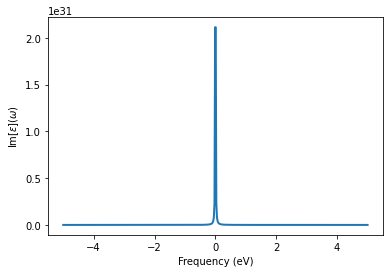

In [ ]:
plt.plot(omega, im_eps, linewidth = 2)
plt.xlabel("Frequency (eV)")
plt.ylabel("Im[$\epsilon$]($\omega$)")
plt.show()

# Load data file to extract vector potential and Current (Equillibrium Calculation)

In [ ]:
probe = np.loadtxt("Act_jt_3.6d8_probe.out")         # Vector potential and Current for equilibrium
time = probe[:, 0]                                 # Time steps
vec_pot =probe[:, 1]                               # Pump/probe field
probe_current = probe[:, 4]                         # Current
electric_field = probe[:, 7]                       # Electric Field

# Plot of vector potential, current, electric field,

<Figure size 500x800 with 0 Axes>

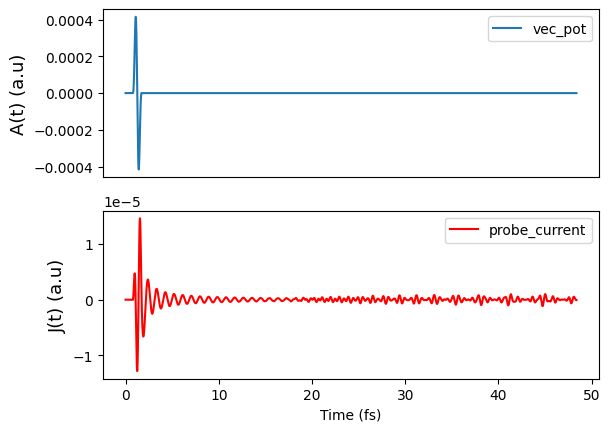

In [ ]:
plt.clf()
fx = plt.figure()
fx.set_figwidth(5)
fx.set_figheight(8)
plt.figure(1)
plt.subplot(2,1,1)
plt.plot(time*au2fs, vec_pot, label = 'vec_pot' )
plt.ylabel(r'A(t) (a.u)', size = 13)
plt.xticks([])
plt.legend()
plt.subplot(2,1,2)
plt.plot(time*au2fs, probe_current, 'r', label = 'probe_current')
plt.ylabel(r'J(t) (a.u)', size = 13)
plt.legend()
plt.xlabel(r'Time (fs)')
plt.show()

#Evaluate the derivative of the vector potential to get the Electric field

$$
\mathbf{E(t)}=-\frac{1}{c} \frac{\partial \mathbf{A(t)}}{\partial t}
$$


In [ ]:
time_dt = time[1]-time[0]
#field = -(1.0/c)*np.gradient(vec_pot, time_dt)

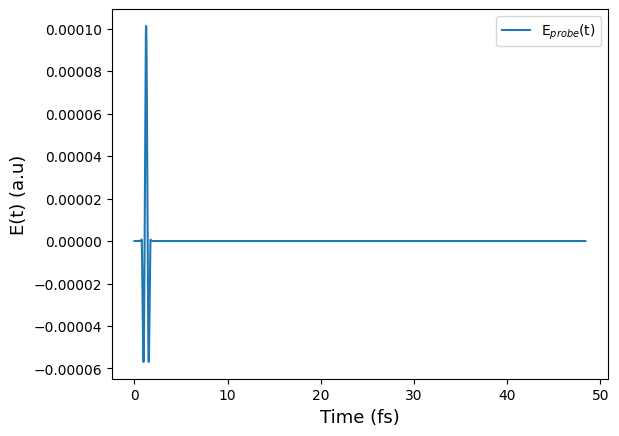

In [ ]:
plt.figure(2)
plt.plot(time*au2fs, electric_field, label= r'E$_{probe}$(t)')
#plt.plot(time*au2fs, field, label= r'E$_{probe}$(t)')
plt.xlabel(r"Time (fs)", size = 13)
plt.ylabel(r"E(t) (a.u)", size = 13)
plt.legend()
plt.show()

# Fourier transform of Current and Electric field
$$
J(\omega)=\int_{T}^{+\infty} J(t) e^{i \omega t - \gamma t} d t \\
E(\omega)=\int_{-\infty}^{+\infty} E(t) e^{i \omega t -  \gamma t} d t
$$

# Energy Axis

In [ ]:
energy = np.linspace(0/h2ev, 20/h2ev, 500)

In [ ]:
def FT(time, probe_current,electric_field, energy):
    global time_dt
    sigOutNum = np.zeros(len(energy)).astype(np.complex128)
    sigOutDenom = np.zeros(len(energy)).astype(np.complex128)
    gamma = 0.25/h2ev  #-np.log(1e-3)/time[-1]
    mask = np.exp(-gamma * time)

    current_tmp = probe_current * mask
    ef_tmp = electric_field * mask

    for ei, ee in enumerate(energy):
        sigOutNum[ei] = np.sum(np.exp(1j * ee * time) * current_tmp) * time_dt
        sigOutDenom[ei] = np.sum(np.exp(1j * ee * time) * ef_tmp) * time_dt

    return sigOutNum, sigOutDenom

Current, Laser = FT(time, probe_current, electric_field, energy)

# Evaluate the Equillibrium optical conductivity
\begin{equation}
\sigma(\omega)=\frac{{J(ω)}}{E({\omega})}
\end{equation}

In [ ]:
equillibrium_sigma = Current / Laser

#Plot of Fourier Transform of Laser

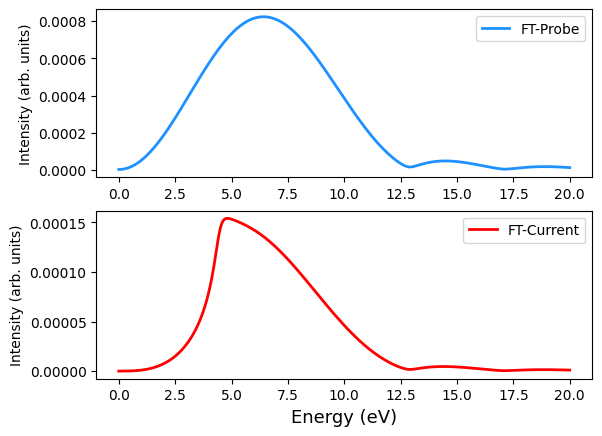

In [ ]:
plt.figure(3)
plt.subplot(2, 1, 1)
plt.plot(energy * h2ev, np.abs((Laser)), label="FT-Probe", color='dodgerblue', linewidth = 2)
plt.ylabel('Intensity (arb. units)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(energy * h2ev, np.abs((Current)), label="FT-Current", color='red', linewidth = 2)
plt.xlabel('Energy (eV)', size = 13)
plt.ylabel('Intensity (arb. units)')
plt.legend()
plt.show()

# Plot of Optical conductivity




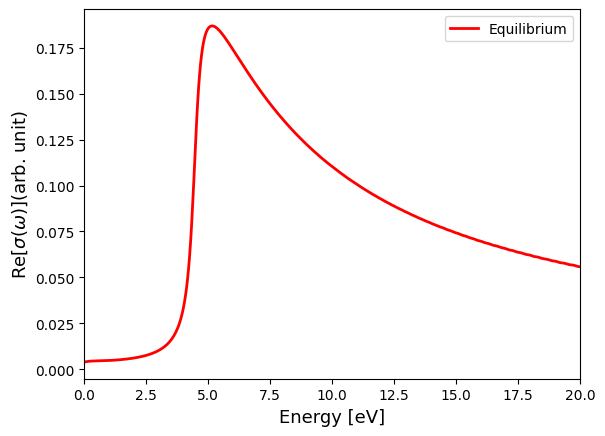

In [ ]:
plt.figure(4)
plt.plot(energy * h2ev, -1.0 * np.real(equillibrium_sigma), linestyle="-", label="Equilibrium", color='red', linewidth = 2)
plt.legend()
plt.xlim(0,20)
plt.xlabel("Energy [eV]", size = 13)
plt.ylabel(r"Re[$\sigma(\omega)$](arb. unit)", size = 13)
plt.show()

# Load the data from reference calcutlaion (Pump Only!!)

In [ ]:
pump = np.loadtxt("Act_jt_3.6d10_pump.out")         # Vector potential and Current for pump only
time = pump[:, 0]                                 # Time steps
vec_pot =pump[:, 1]                               # Pump
pump_current = pump[:, 4]                         # Current
pump_field = pump[:, 7]                           # Electric Field

# Load Pump-probe data file

In [ ]:
trans = np.loadtxt("Act_jt_3d10_3d8_pp.out")            # Vector potential and Current file for pumpprobe calculations
trans_time = trans[:, 0]                                                  # Time steps
trans_vecpot =trans[:, 1]                                                 # Pump vector potential
trans_current = trans[:, 4]                                               # Current
trans_efield = trans[:, 7]

# Split the data into chunks of 50001 lines

In [ ]:
num_lines = 50001                                    # Number of lines that data set is seperated
num_chunks = int(trans.shape[0] / num_lines)
trans_chunks = np.array_split(trans, num_chunks)

# Plot each chunk of data for Vector potential and Current

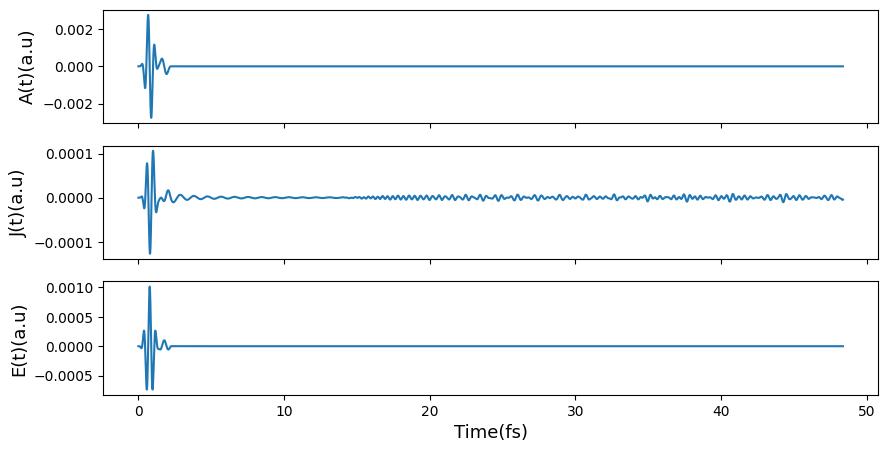

In [ ]:
#%matplotlib notebook
fig, axs = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for datachunk in trans_chunks:
    axs[0].plot(datachunk[:,0]*au2fs, datachunk[:,1])
    #axs[0].set_xlabel("Time(a.u)", size = 13)
    axs[0].set_ylabel(r"A(t)(a.u)", size = 13)
    #axs[0].legend()

for datachunk in trans_chunks:
    axs[1].plot(datachunk[:,0]*au2fs, datachunk[:,4])
    #axs[1].set_xlabel("Time(fs)", size = 13)
    axs[1].set_ylabel(r"J(t)(a.u)", size = 13)

for datachunk in trans_chunks:
    axs[2].plot(datachunk[:,0]*au2fs, datachunk[:,7])
    axs[2].set_xlabel("Time(fs)", size = 13)
    axs[2].set_ylabel(r"E(t)(a.u)", size = 13)

plt.show()

# Extract Probe Electric Field

# $$E_{probe}(t) = E_{pumpprobe}(t) - E_{pump}(t)$$

In [ ]:
trans_efield_portions = np.array_split(trans_efield, len(trans_efield)//50001)
trans_probe_efield = [trans_efield_portions[i] - pump_field for i in range(len(trans_efield_portions))]

In [ ]:
trans_probe_efield = np.array(trans_efield - pump_field)

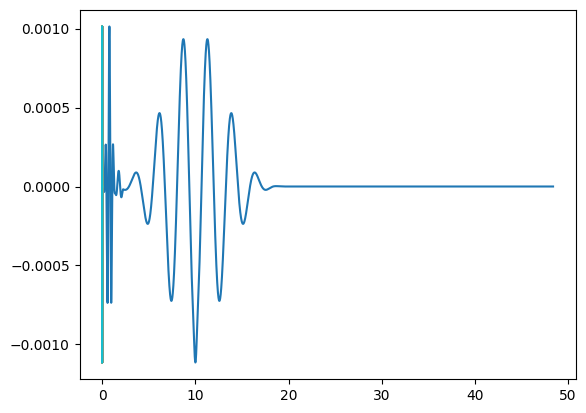

In [ ]:
plt.plot(trans*au2fs, trans_probe_efield)

#Plot of Transient Probe E-Field



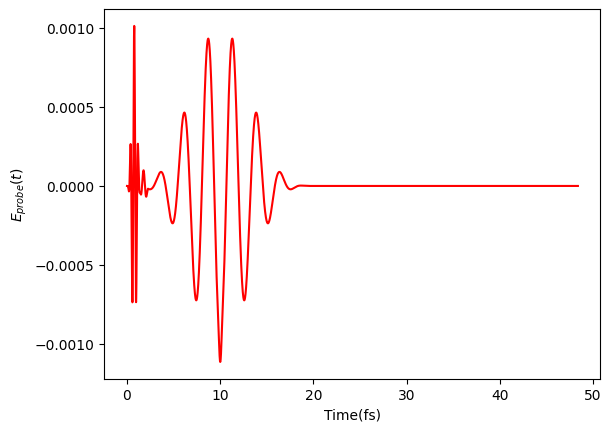

In [ ]:
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

plt.figure()
# iterate over the chunks
for i, portions in enumerate(trans_probe_efield):
     plt.plot(trans[i*50001:i*50001+50001,0]*au2fs, portions, color=colors[i%len(colors)])

plt.xlabel(r"Time(fs)")
plt.ylabel(r"$E_{probe}(t)$")
plt.show()

# split trans_current into chunks of 50001 lines

In [ ]:
trans_current_portions = np.array_split(trans_current, len(trans_current)//50001)

# Subtract the Pumpprobe Current from Pump only
\begin{equation}
\vec{J}_{\text {probe }}(t):=\vec{J}_{\text {pump probe }}(t)- \vec{J}_{\text {pump }}(t)
\end{equation}

In [ ]:
trans_probe_current = [trans_current_portions[i] - pump_current for i in range(len(trans_current_portions))]

In [ ]:
len(trans_current_portions[0]), len(trans_probe_current)

(50001, 39)

# Plot of Transient Probe Current

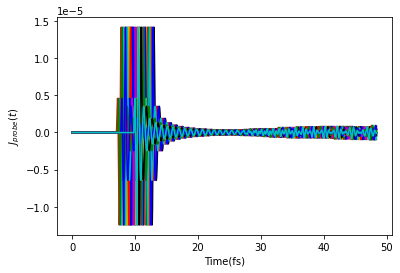

In [ ]:
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

plt.figure()
# iterate over the chunks
for i, portions in enumerate(trans_probe_current):
     plt.plot(trans[i*50001:i*50001+50001,0]*au2fs, portions, color=colors[i%len(colors)])

plt.xlabel(r"Time(fs)")
plt.ylabel(r"$J_{probe}(t)$")
plt.show()

# Calculate the Fourier Transform of the Probe Current and Probe Electric field

# Energy and Time axis

In [ ]:
trans_energy  = np.linspace(0/h2ev, 20/h2ev, 500)
trans_time_dt = trans_time[1] - trans_time[0]
transprobe_time_portions = np.array_split(trans_time, len(trans_time)//50001)

NameError: ignored

# Fourier Transform of transient Probe Currrent and Transient Probe electric field

In [ ]:
def FT(transprobe_time_portions, trans_probe_current, trans_probe_efield, trans_energy):
    global trans_time_dt
    sigOutNum = []
    sigOutDenom = []

    gamma = 1.25/27.2114

    tt = np.array(transprobe_time_portions[0][:])
    trans_probe_current = np.array(trans_probe_current)
    trans_probe_efield_portions = np.array(trans_probe_efield)
    mask = np.exp(-gamma * tt)
    ppcurrent_tmp = trans_probe_current *mask
    ppef_tmp = trans_probe_efield_portions *mask
    ee = trans_energy

    FTmat=np.exp(1j*ee[None,:]*tt[:,None])

    sigOutNum = np.sum((FTmat)[None,:,:]*ppcurrent_tmp[:,:,None], axis=1)* trans_time_dt
    sigOutDenom = np.sum((FTmat)[None,:,:]*ppef_tmp[:,:,None], axis=1)* trans_time_dt
    # print((FTmat)[None,:,:]*ppcurrent_tmp[:,:,None]).shape)

    return sigOutNum, sigOutDenom

tas_current, tas_laser =  FT(transprobe_time_portions, trans_probe_current, trans_probe_efield, trans_energy)

NameError: ignored

# Plot of the FT of Transient Probe and Transient Current

In [ ]:
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(np.multiply(trans_energy, h2ev), np.abs((tas_laser)).T,)# color='dodgerblue', linewidth = 2)
#plt.xlabel('Energy (eV)', size = 13)
plt.ylabel('Intensity(arb. Units)')
#plt.legend()
plt.subplot(2, 1, 2)
plt.plot(np.multiply(trans_energy, h2ev), np.abs((tas_current)).T,)# label="FT-Current", color='red', linewidth = 2)
plt.xlabel('Energy (eV)', size = 13)
plt.ylabel('Intensity(arb. Units)')
#plt.legend()
plt.show()

# Take the ratio of current to laser
\begin{equation}
\tilde{\sigma}(\omega, T)=\frac{{J(ω)}}{E({\omega})}
\end{equation}

In [ ]:
tas_current , tas_laser =  np.array(tas_current),np.array(tas_laser)
tas_sigma =  (tas_current/tas_laser).T

# Plot of tas_sigma

In [ ]:
plt.plot(np.multiply(trans_energy, h2ev), -1.0*np.real((tas_sigma)))
plt.plot(np.multiply(trans_energy, h2ev), -1.0*np.real((equillibrium_sigma)))
plt.xlabel('Energy (eV)', size = 13)
plt.ylabel(r"Re[$\sigma(\omega)$](arb. Units)", size = 13)
plt.show()

 # Subtract the tas_sigma from the equillibrium sigma to obtain TAS

In [ ]:
equillibrium_sigma = equillibrium_sigma.reshape(-1, 1)
trans_diff = np.subtract((tas_current / tas_laser).T, equillibrium_sigma)

In [ ]:
plt.plot(trans_energy*h2ev, -1.0*np.real(trans_diff))
plt.xlabel('Energy (eV)', size = 13)
plt.ylabel(r"Re[$\sigma(\omega,T)-\sigma(\omega,0)](arb. Units)$]", size = 13)
plt.show()

#Density plot to obtain the TAS!!


In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot(111)
# vmin = -1.0*np.real(trans_diff)
# vmax = 1.0*np.real(trans_diff)
X, Y = np.meshgrid(np.linspace(0, 39, 39), np.linspace(min(trans_energy*h2ev), max(trans_energy*h2ev), 500))
#fig, ax = plt.subplots()
pos = ax.pcolormesh(X, Y, -1.0*(np.real(trans_diff)), cmap='seismic')
fig.colorbar(pos, ax=ax)
#plt.ylim(0,5)
plt.xlabel('Time Delay (fs)', size = 12)
plt.ylabel('Energy (eV)', size = 12)
#plt.savefig('TAS_Monolayer_hBN.png', dpi=300)
plt.show()

In [ ]:
fig = plt.figure(figsize=(3, 2))
ax = fig.add_subplot(111)
vmin = -0.001#-1.0*np.max(np.abs(trans_diff))
vmax = 0.001  # 1.0* np.max(np.abs(trans_diff))
X, Y = np.meshgrid(np.linspace(0, 39, 39), np.linspace(min(trans_energy*h2ev), max(trans_energy*h2ev), 500))
plt.ylim(0,5)
#fig, ax = plt.subplots()
pos = ax.pcolormesh(X, Y, 1.0*np.real(trans_diff), cmap='seismic', vmin=vmin,vmax=vmax)
fig.colorbar(pos, ax=ax)
#plt.ylim(0,5)
plt.xlabel('Time Delay (fs)', size = 12)
plt.ylabel('Energy (eV)', size = 12)
plt.show()

#Reference
https://www.mdpi.com/2076-3417/8/10/1777